In [1]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Dataset upload
df_path = Path.cwd().parent.parent / 'data' / 'processed' / 'dataset.csv'
df = pd.read_csv(df_path)
print(f"Nulls Quantity:\n{df.isna().sum()}")

Nulls Quantity:
subject_id             0
video_id               0
window_id              0
frame_window_id        0
angle_left_shoulder    0
                      ..
x_28                   0
y_28                   0
z_28                   0
v_28                   0
class                  0
Length: 61, dtype: int64


## Dataset Analysis

We can start by examining the number of frames whose angle difference from the immediately preceding frame is greater than 30°. We chose this approach because it is humanly impossible to move a joint at a higher speed.

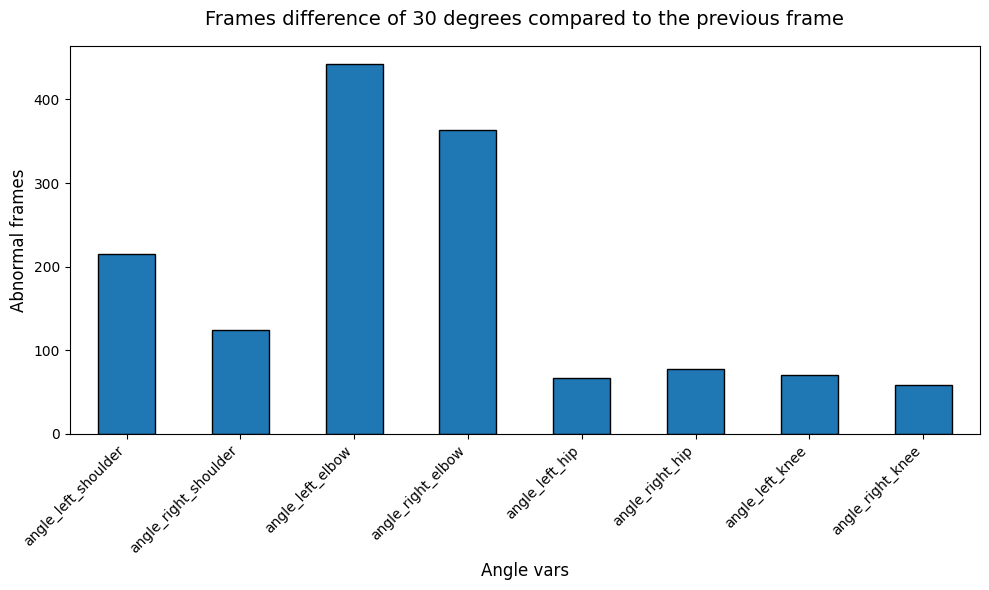

In [2]:
df_clean_angles = df.copy()
# Angle columns list
angle_columns = [col for col in df_clean_angles.columns if 'angle' in col]

# Threshold for joint angle speed
max_angle_jump = 30 #Degrees

# _____Frames analysis that exceed the angle movement limit_____
angle_outliner = df_clean_angles.groupby('window_id')[angle_columns].diff().abs() > max_angle_jump

err_by_window = angle_outliner.sum()

plt.figure(figsize=(10, 6))
err_by_window.plot(kind='bar', edgecolor='black')
plt.title('Frames difference of 30 degrees compared to the previous frame', fontsize=14, pad=15)
plt.xlabel('Angle vars', fontsize=12)
plt.ylabel('Abnormal frames', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
# ____________________________________________________________________________________        

We can observe that the number of anomalous frames per angle variable is much higher in the elbows.

Now, let's look at the proportion of errors per dataframe window. We will consider an error proportion greater than 15% to be high.

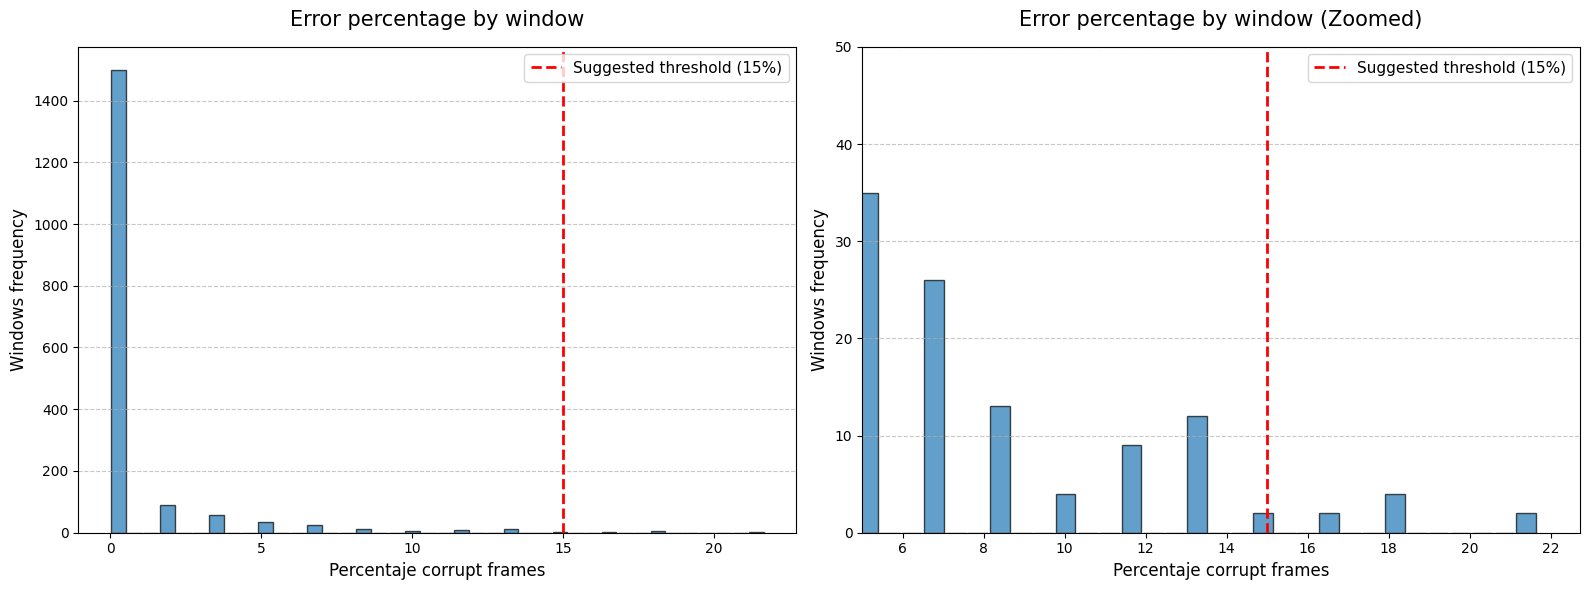

In [3]:
# Wors angle error by window
pct_err_by_window = angle_outliner.groupby(df_clean_angles['window_id']).mean() * 100
worst_err = pct_err_by_window.max(axis=1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Full plot
ax1.hist(worst_err, bins=40, color='#1f77b4', edgecolor='black', alpha=0.7, rwidth=0.9)
ax1.axvline(x=15, color='red', linestyle='--', linewidth=2, 
            label=f'Suggested threshold ({15}%)')
ax1.grid(axis='y', linestyle='--', alpha=0.7)
ax1.set_title('Error percentage by window', fontsize=15, pad=15)
ax1.set_xlabel('Percentaje corrupt frames', fontsize=12)
ax1.set_ylabel('Windows frequency', fontsize=12)
ax1.legend(fontsize=11)

# Zoomed plot
ax2.hist(worst_err, bins=40, color='#1f77b4', edgecolor='black', alpha=0.7, rwidth=0.9)
ax2.axvline(x=15, color='red', linestyle='--', linewidth=2, 
            label=f'Suggested threshold ({15}%)')
ax2.grid(axis='y', linestyle='--', alpha=0.7)
ax2.set_title('Error percentage by window (Zoomed)', fontsize=15, pad=15)
ax2.set_xlabel('Percentaje corrupt frames', fontsize=12)
ax2.set_xlim(5)
ax2.set_ylabel('Windows frequency', fontsize=12)
ax2.set_ylim((0,50))
ax2.legend(fontsize=11)

plt.tight_layout()
plt.show()

We can see that most videos do not present any type of error.

Let's move on to analyzing visibility.

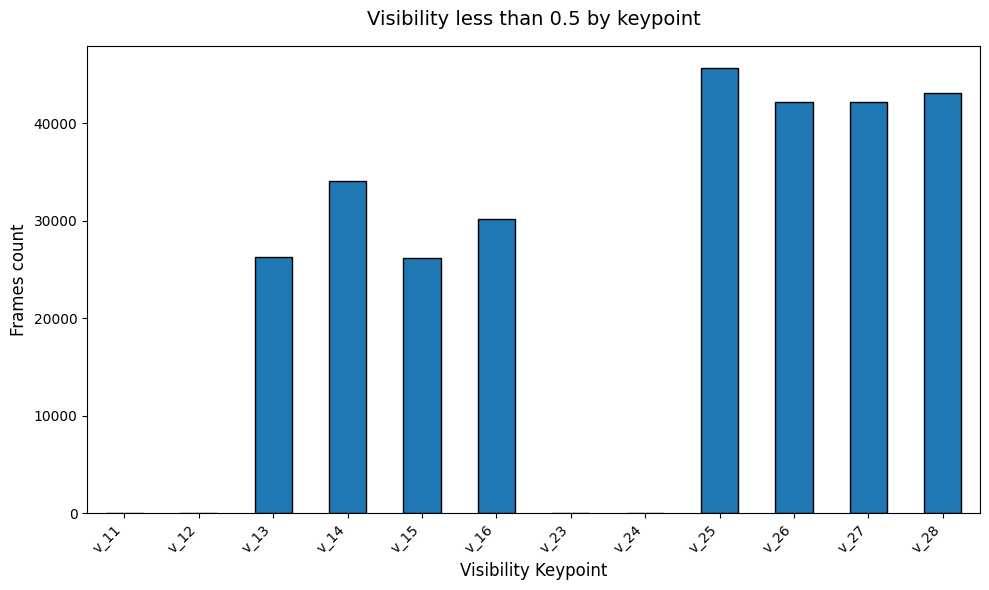

In [4]:
# Visibility columns list
visibility_columns = [col for col in df_clean_angles.columns if 'v_' in col]

# Threshold for visibility
min_visibility = 0.5

# _____Visibility analysis_____
visibility_outliner = df_clean_angles[visibility_columns] < min_visibility

err_v_by_keypoint = visibility_outliner.sum()

plt.figure(figsize=(10, 6))
err_v_by_keypoint.plot(kind='bar', edgecolor='black')
plt.title('Visibility less than 0.5 by keypoint', fontsize=14, pad=15)
plt.xlabel('Visibility Keypoint', fontsize=12)
plt.ylabel('Frames count', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
# ____________________________________________________________________________________    

In the previous graph, we can see how the filter applied in the data extraction script works correctly to discard frames with a hip visibility lower than 0.3 (in the graph, we set the visibility threshold to 0.5). Additionally, despite the absence of any filter on the points corresponding to the shoulders (v_11, v_12), there is no frame with a visibility lower than 0.5 at these points.

If we look at the rest of the variables, we can observe that the proportion of frames where visibility is lower than 0.5 on the left side (v_13, v_15, v_25, v_27) is very similar to the right side (v_14, v_16, v_26, v_28). Initially, this is completely normal, as the video selection includes videos taken from all perspectives.

Let's see which videos have a higher number of frames with visibility lower than 0.5.

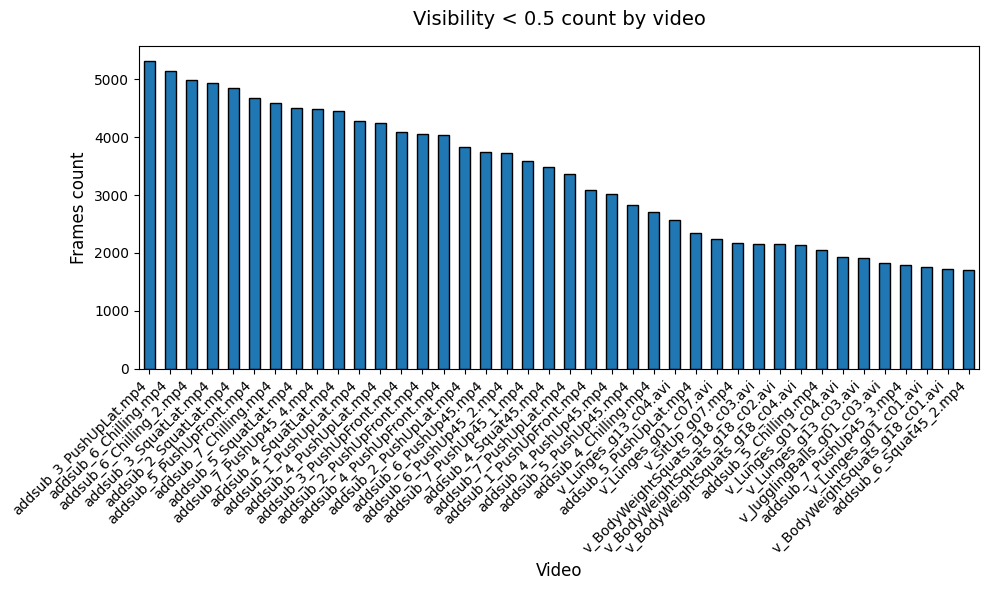

In [5]:
#Visibility < 0.5 count by video
err_v_by_video = visibility_outliner.sum(axis=1).groupby(df_clean_angles['video_id']).sum().sort_values(ascending=False).head(40)

plt.figure(figsize=(10, 6))
err_v_by_video.plot(kind='bar', edgecolor='black')
plt.title('Visibility < 0.5 count by video', fontsize=14, pad=15)
plt.xlabel('Video', fontsize=12)
plt.ylabel('Frames count', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The previous graph on its own does not tell us anything interesting. What we do know is that the "addsub_" videos we added are longer than those from the UCF101 dataset, so it is logical that they have a higher number of errors.

Let's analyze how the pose points behave throughout the video with the highest number of frames with visibility lower than 0.5.

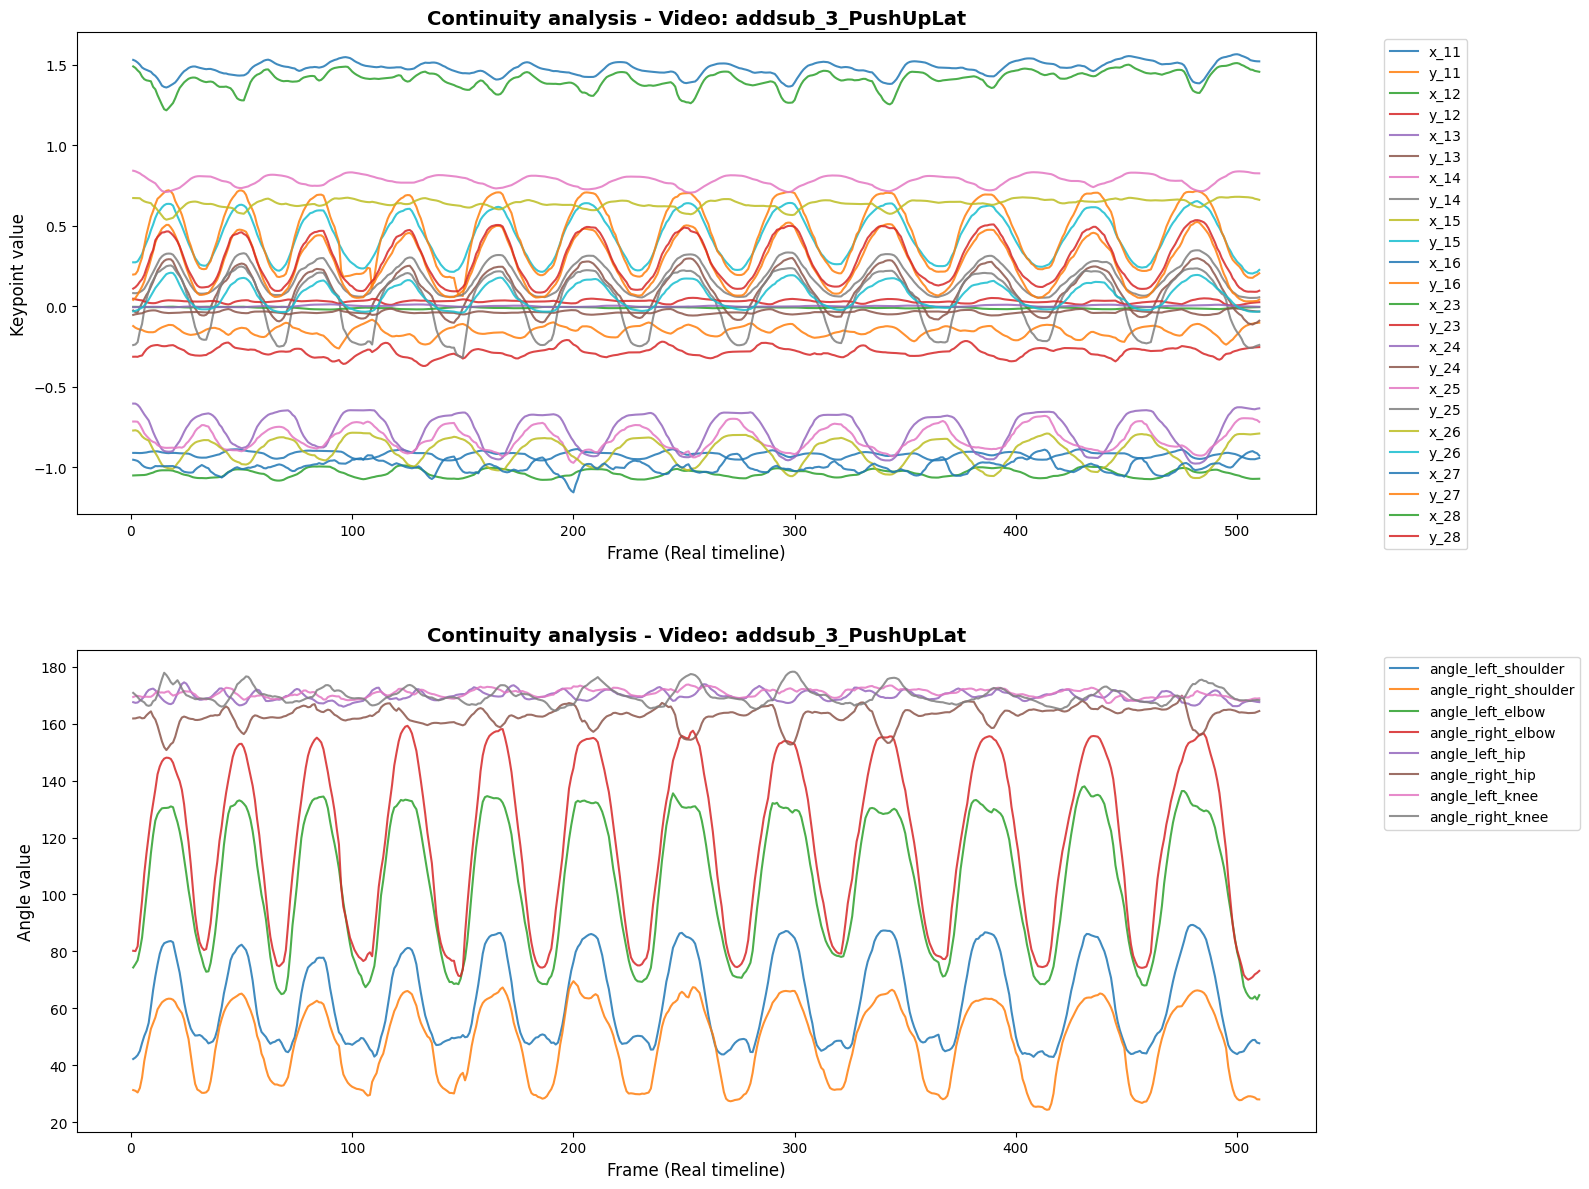

In [6]:
# Video name filter
video_name = err_v_by_video.index[0].rsplit('.')[0]
df_video_name = df_clean_angles[df_clean_angles['video_id'].str.contains(video_name)].copy()

# Video window_num
window_num = df_video_name['window_id'].str.rsplit(video_name + '_').str[1].astype(int)

# Absolute video frame calculation
absolute_frame = (window_num - 1) * 30 + df_clean_angles['frame_window_id']
video_absolute_frame = absolute_frame[absolute_frame.notna()]
df_video_name['absolute_frame'] = video_absolute_frame

df_video_stream = df_video_name.drop_duplicates(subset=['absolute_frame'], keep='first').sort_values('absolute_frame')

# Plot preparation
pose_columns = [col for col in df_video_stream.columns if 'x_' in col or 'y_' in col]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12))

for col in pose_columns: 
    ax1.plot(df_video_stream['absolute_frame'], df_video_stream[col], label=col, alpha=0.85, linewidth=1.5)
ax1.set_title(f'Continuity analysis - Video: {video_name}', fontsize=14, fontweight='bold')
ax1.set_xlabel('Frame (Real timeline)', fontsize=12)
ax1.set_ylabel('Keypoint value', fontsize=12)
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

for angle in angle_columns: 
    ax2.plot(df_video_stream['absolute_frame'], df_video_stream[angle], label=angle, alpha=0.85, linewidth=1.5)
ax2.set_title(f'Continuity analysis - Video: {video_name}', fontsize=14, fontweight='bold')
ax2.set_xlabel('Frame (Real timeline)', fontsize=12)
ax2.set_ylabel('Angle value', fontsize=12)
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

We can see that there are no abrupt jumps in the keypoint positions, and a very clear pattern of rises and falls can be seen, corresponding to repetitions of an exercise. Let's apply the same analysis to a video from the UCF101 dataset, "v_BodyWeightSquats_g18".

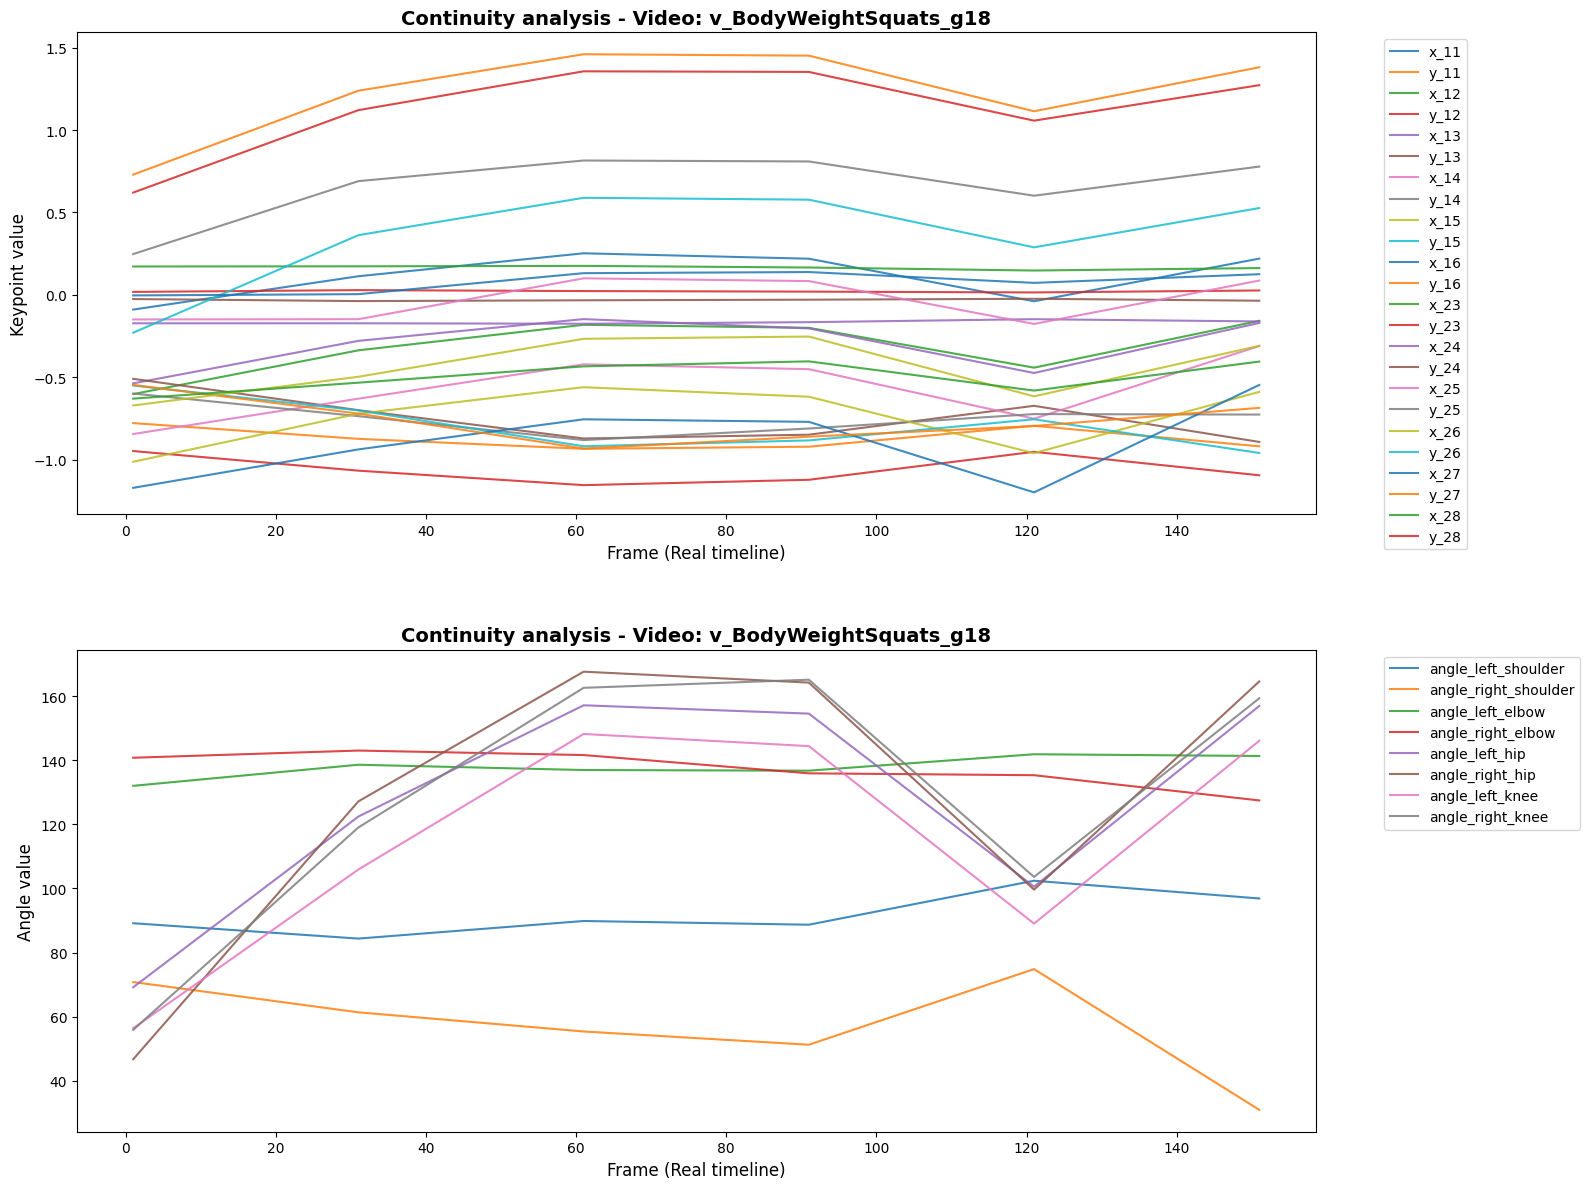

In [7]:
# Video name filter
subject_id = "v_BodyWeightSquats_g18"
df_video_name = df_clean_angles[df_clean_angles['subject_id'].str.contains(subject_id)].copy()

#Video subject identifier
window_num = df_video_name['window_id'].str.extract(r'(\d+)$').astype(int)

# Absolute video frame calculation
absolute_frame = (window_num - 1) * 30 + df_clean_angles['frame_window_id']
video_absolute_frame = absolute_frame[0]
df_video_name['absolute_frame'] = video_absolute_frame
df_video_stream = df_video_name.drop_duplicates(subset=['absolute_frame'], keep='first').sort_values('absolute_frame')

# Plot preparation
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12))

for col in pose_columns: 
    ax1.plot(df_video_stream['absolute_frame'], df_video_stream[col], label=col, alpha=0.85, linewidth=1.5)
ax1.set_title(f'Continuity analysis - Video: {subject_id}', fontsize=14, fontweight='bold')
ax1.set_xlabel('Frame (Real timeline)', fontsize=12)
ax1.set_ylabel('Keypoint value', fontsize=12)
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

for angle in angle_columns: 
    ax2.plot(df_video_stream['absolute_frame'], df_video_stream[angle], label=angle, alpha=0.85, linewidth=1.5)
ax2.set_title(f'Continuity analysis - Video: {subject_id}', fontsize=14, fontweight='bold')
ax2.set_xlabel('Frame (Real timeline)', fontsize=12)
ax2.set_ylabel('Angle value', fontsize=12)
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

The result is similar; there are no abrupt changes, and the repetitions can be perceived.

## Data Cleaning

For cleaning, we will only consider frames whose angle difference from the previous frame is greater than 30°, as this is considered humanly impossible. To address this, we will draw a mathematical line between the previous and next frames to smooth the angle change between frames.

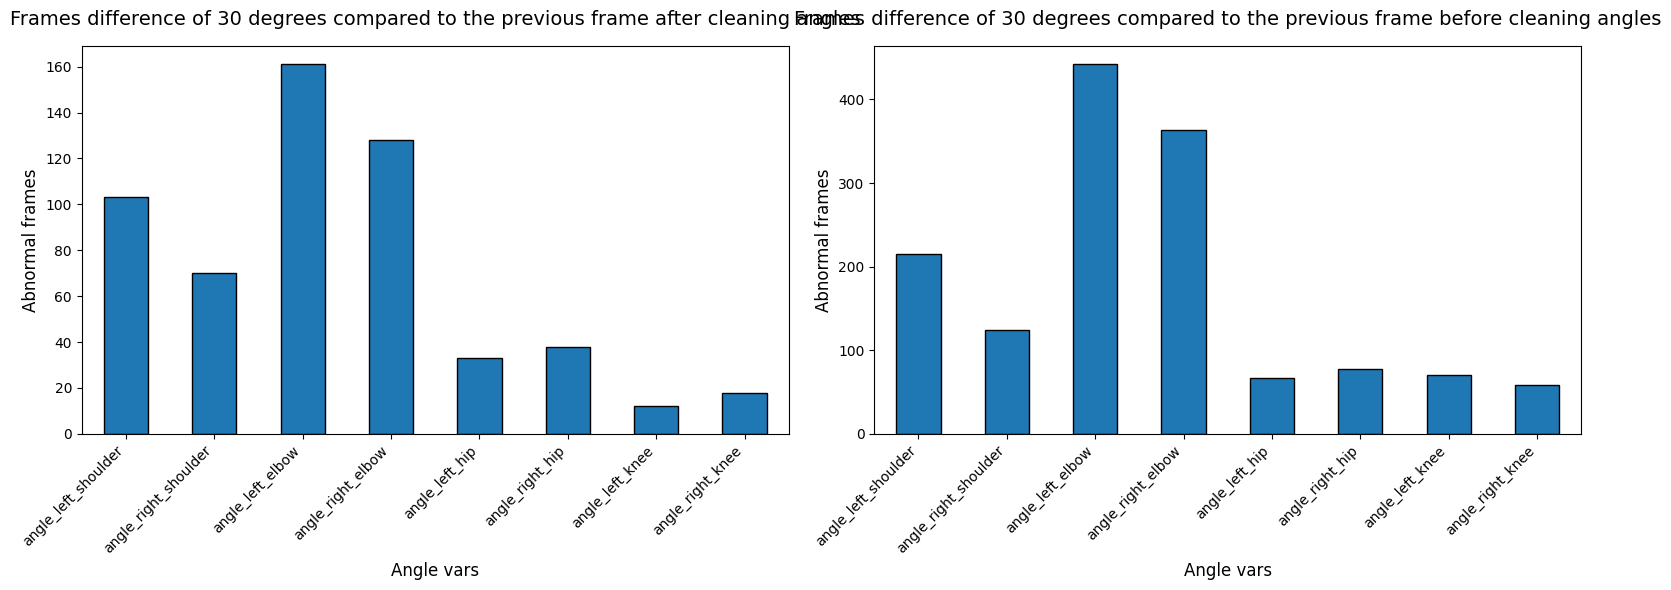

In [8]:
df_final = df.copy()
df_final[angle_columns] = df_clean_angles[angle_columns].mask(angle_outliner)

df_final[angle_columns] = df_final.groupby('window_id')[angle_columns].transform(
    lambda x: x.interpolate(method='linear', limit_direction='both')
)

# _____Frames analysis that exceed the angle movement limit_____
new_angle_outliner = df_final.groupby('window_id')[angle_columns].diff().abs() > max_angle_jump

new_err_by_window = new_angle_outliner.sum()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

new_err_by_window.plot(kind='bar', edgecolor='black',ax=ax1)
ax1.set_title('Frames difference of 30 degrees compared to the previous frame after cleaning angles', fontsize=14, pad=15)
ax1.set_xlabel('Angle vars', fontsize=12)
ax1.set_ylabel('Abnormal frames', fontsize=12)
plt.setp(ax1.get_xticklabels(), rotation=45, ha='right')

err_by_window.plot(kind='bar', edgecolor='black', ax=ax2)
ax2.set_title('Frames difference of 30 degrees compared to the previous frame before cleaning angles', fontsize=14, pad=15)
ax2.set_xlabel('Angle vars', fontsize=12)
ax2.set_ylabel('Abnormal frames', fontsize=12)
plt.setp(ax2.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

We can observe that by applying the previous processing, the number of frames with an angle change greater than 30° is drastically reduced. Let's see if any window exceeds 15% corrupted frames and how the proportion of frames per window has changed.

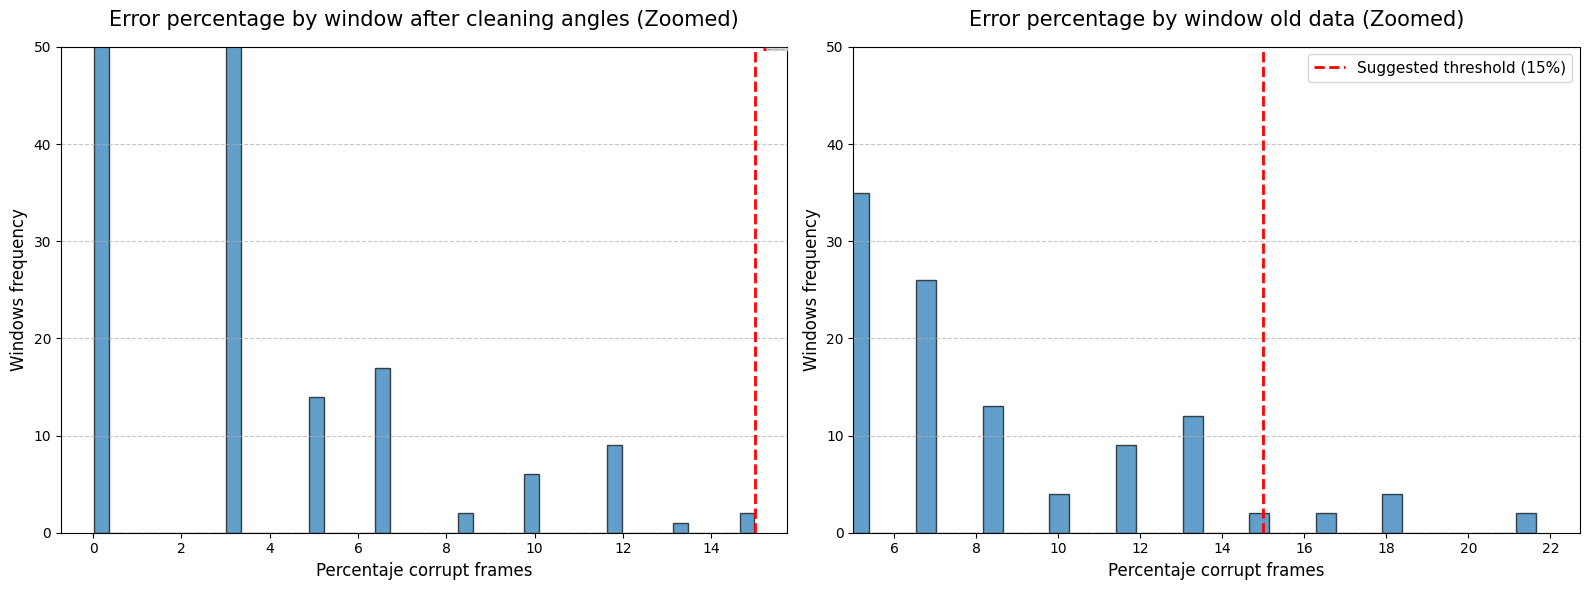

In [9]:
pct_err_by_window = new_angle_outliner.groupby(df_clean_angles['window_id']).mean() * 100
new_worst_err = pct_err_by_window.max(axis=1)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# New Data
ax1.hist(new_worst_err, bins=40, color='#1f77b4', edgecolor='black', alpha=0.7, rwidth=0.9)
ax1.axvline(x=15, color='red', linestyle='--', linewidth=2, 
            label=f'Suggested threshold ({15}%)')
ax1.grid(axis='y', linestyle='--', alpha=0.7)
ax1.set_title('Error percentage by window after cleaning angles (Zoomed)', fontsize=15, pad=15)
ax1.set_xlabel('Percentaje corrupt frames', fontsize=12)
ax1.set_ylabel('Windows frequency', fontsize=12)
ax1.set_ylim((0,50))
ax1.legend(fontsize=1)

# Old Data
ax2.hist(worst_err, bins=40, color='#1f77b4', edgecolor='black', alpha=0.7, rwidth=0.9)
ax2.axvline(x=15, color='red', linestyle='--', linewidth=2, 
            label=f'Suggested threshold ({15}%)')
ax2.grid(axis='y', linestyle='--', alpha=0.7)
ax2.set_title('Error percentage by window old data (Zoomed)', fontsize=15, pad=15)
ax2.set_xlabel('Percentaje corrupt frames', fontsize=12)
ax2.set_xlim(5)
ax2.set_ylabel('Windows frequency', fontsize=12)
ax2.set_ylim((0,50))
ax2.legend(fontsize=11)

plt.tight_layout()
plt.show()

The result obtained is as expected after cleaning. The number of corrupted frames has decreased, improving data stability and the overall quality of the dataset.

In [10]:
df_final.to_csv(Path.cwd().parent.parent / 'data' / 'processed' / 'final_dataset.csv', index=False)